# Customer Churn Prediction — Exploratory Data Analysis

This notebook explores customer demographics, churn distribution, service usage,
billing/revenue patterns, and feature correlations for the Telco churn dataset.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from preprocessing import load_data, clean_data
from feature_engineering import engineer_features

sns.set_style('whitegrid')
%matplotlib inline

df = load_data('../data/raw/telco_churn.csv')
df = clean_data(df)
df = engineer_features(df)
df.head()

2026-07-07 17:50:48 | INFO     | preprocessing | Loading data from ../data/raw/telco_churn.csv


2026-07-07 17:50:48 | INFO     | preprocessing | Validation: 5005 rows, 5 duplicate rows, 30 total missing values.


2026-07-07 17:50:48 | INFO     | preprocessing | Removed 5 duplicate rows.


2026-07-07 17:50:48 | INFO     | preprocessing | Imputed 30 missing values in 'TotalCharges' with median=1925.70


2026-07-07 17:50:48 | INFO     | preprocessing | Capped 2 outliers in 'TotalCharges' to [-3394.35, 8020.05]


2026-07-07 17:50:48 | INFO     | feature_engineering | Engineering features...


2026-07-07 17:50:49 | INFO     | feature_engineering | Feature engineering complete. Shape: (5000, 29)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TotalCharges,Churn,TenureGroup,AvgMonthlySpend,SpendTrend,RevenuePerTenure,EstimatedFutureValue,ServiceUsageScore,EngagementScore,RiskScore
0,CUST-100000,Male,0,No,No,61,Yes,Yes,Fiber optic,No,...,5879.83,0,4+ Years,96.390656,0.039344,94.835968,2314.32,5,80.6,20.0
1,CUST-100001,Female,0,No,Yes,33,No,No phone service,DSL,No,...,1655.73,0,2-4 Years,50.173636,-0.333636,48.697941,1196.16,1,51.7,18.0
2,CUST-100002,Female,1,Yes,Yes,50,Yes,No,Fiber optic,No,...,5121.92,0,4+ Years,102.438400,-0.008400,100.429804,102.43,4,41.1,55.0
3,CUST-100003,Male,0,Yes,No,70,Yes,No,No,No internet service,...,1757.01,0,4+ Years,25.100143,-0.060143,24.746620,600.96,1,72.2,0.0
4,CUST-100004,Male,0,No,No,3,Yes,Yes,Fiber optic,No,...,265.26,0,0-6 Months,88.420000,1.870000,66.315000,90.29,3,11.7,82.5


## 1. Churn Distribution

Churn
0    3660
1    1340
Name: count, dtype: int64

Churn rate: 26.80%


/tmp/ipykernel_526/2896343273.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, ax=ax, palette=['#10b981', '#ef4444'])
/tmp/ipykernel_526/2896343273.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Churn', 'Churn'])


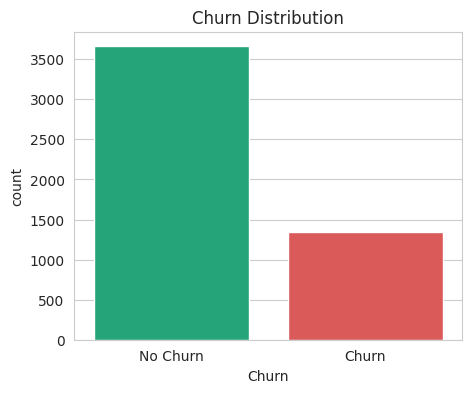

In [2]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn rate: {df['Churn'].mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x='Churn', data=df, ax=ax, palette=['#10b981', '#ef4444'])
ax.set_xticklabels(['No Churn', 'Churn'])
ax.set_title('Churn Distribution')
plt.show()

## 2. Customer Demographics

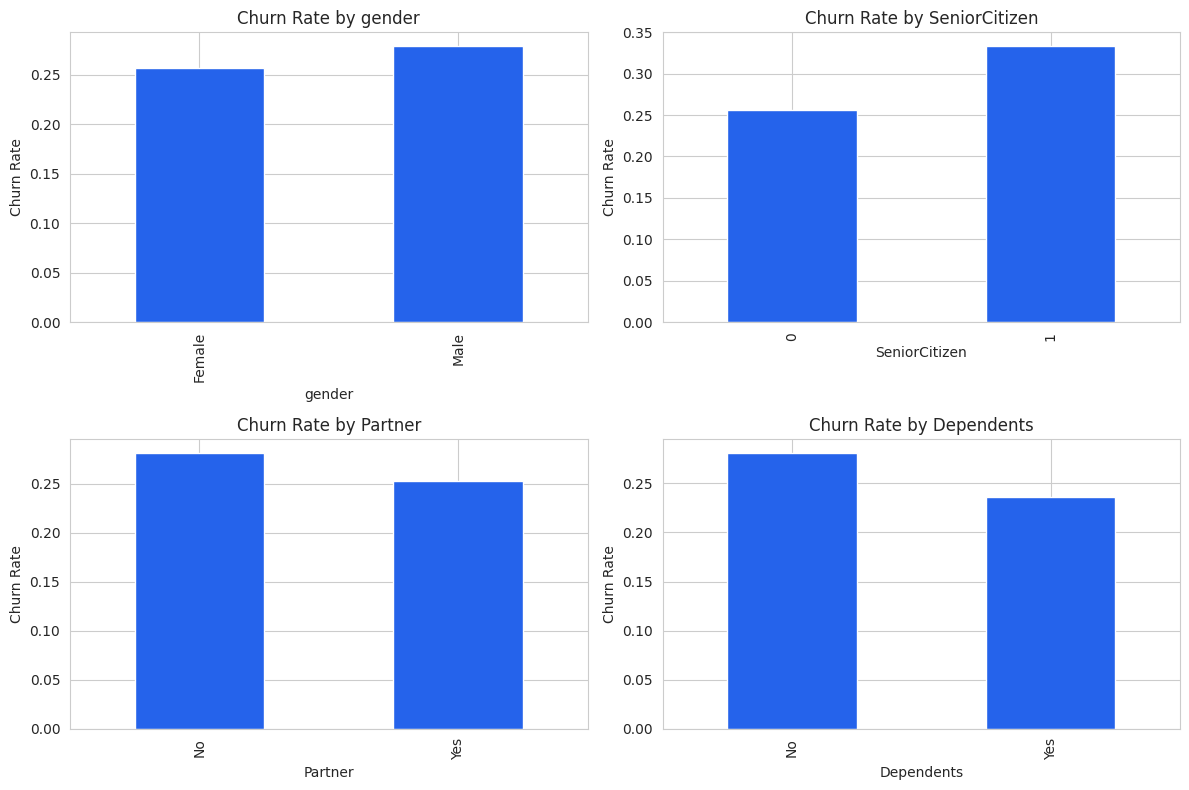

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, ['gender', 'SeniorCitizen', 'Partner', 'Dependents']):
    churn_rate = df.groupby(col)['Churn'].mean()
    churn_rate.plot(kind='bar', ax=ax, color='#2563eb')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

## 3. Correlation Heatmap (Numeric Features)

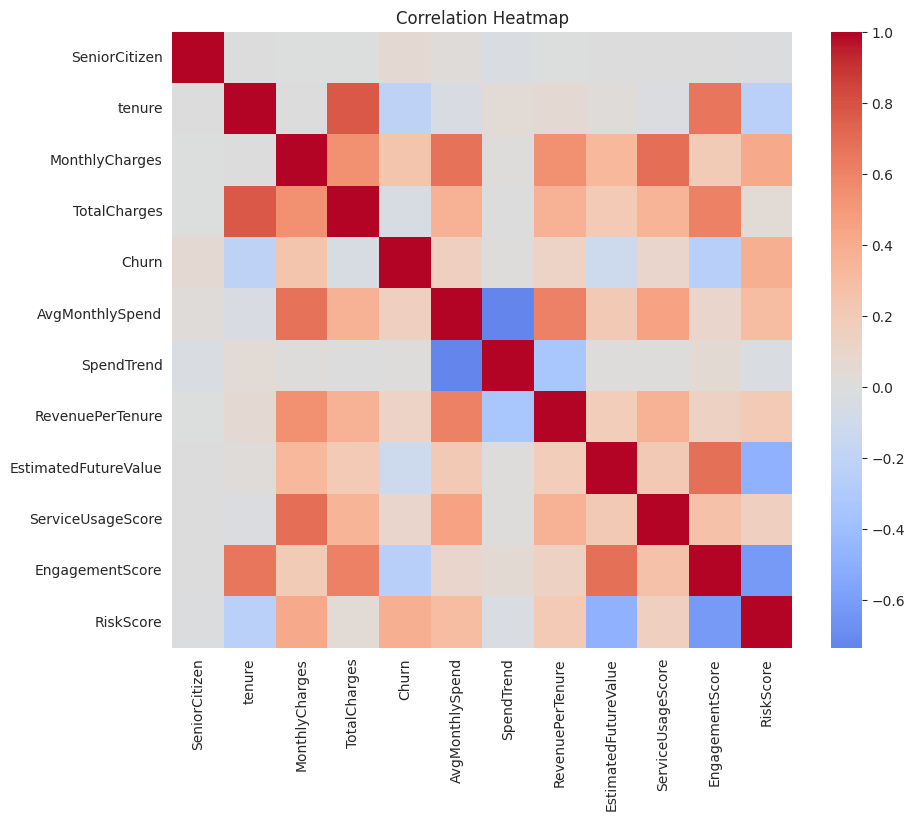

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, ax=ax)
ax.set_title('Correlation Heatmap')
plt.show()

## 4. Service Usage Analysis

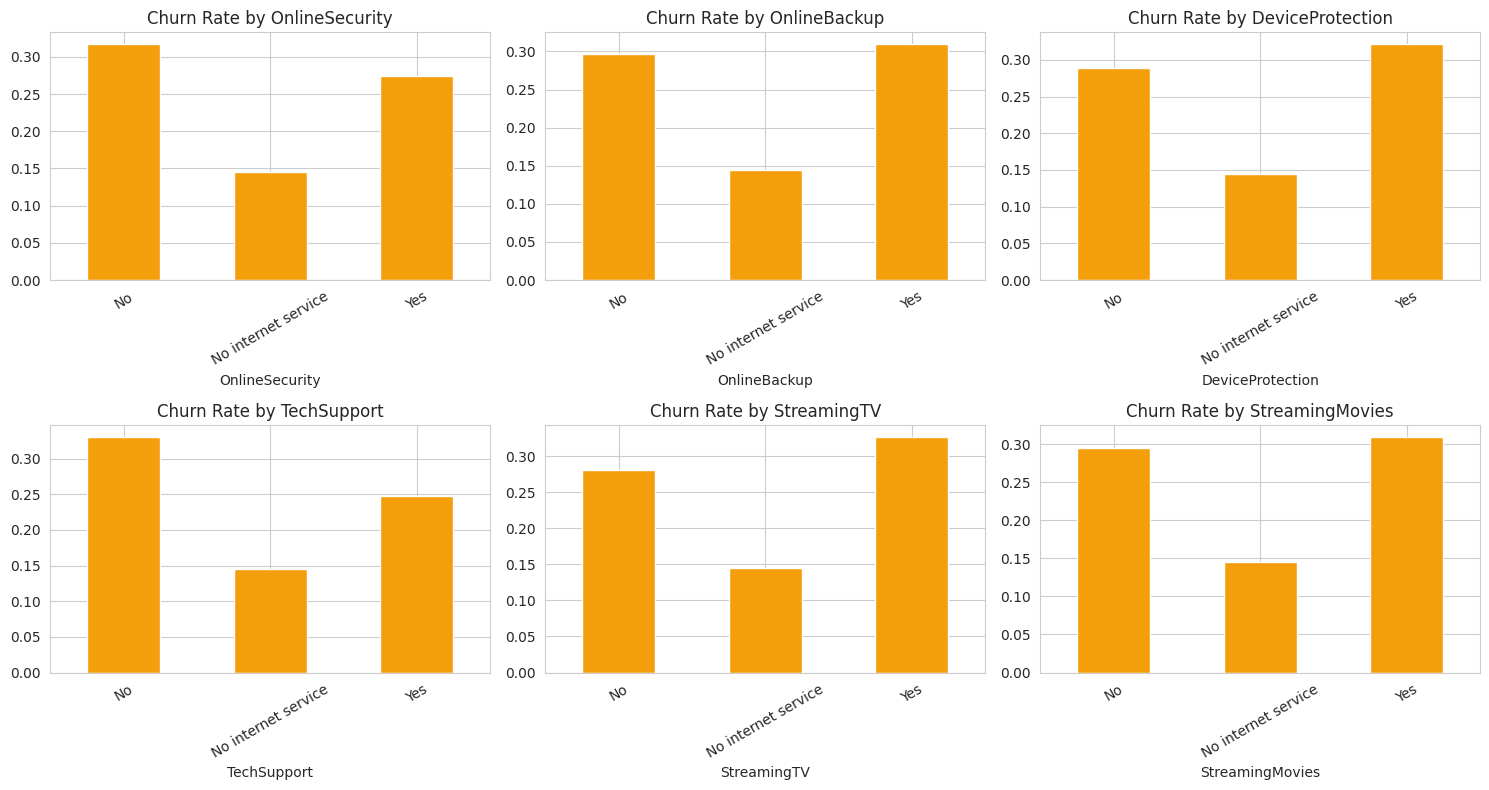

In [5]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, service_cols):
    churn_rate = df.groupby(col)['Churn'].mean()
    churn_rate.plot(kind='bar', ax=ax, color='#f59e0b')
    ax.set_title(f'Churn Rate by {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 5. Revenue Analysis

In [6]:
fig = px.box(df, x='Churn', y='MonthlyCharges', color='Churn',
             color_discrete_map={0: '#10b981', 1: '#ef4444'},
             title='Monthly Charges by Churn Status')
fig.show()

fig2 = px.scatter(df.sample(min(1000, len(df))), x='tenure', y='MonthlyCharges', color='Churn',
                   color_continuous_scale='RdYlGn_r', title='Tenure vs Monthly Charges',
                   opacity=0.6)
fig2.show()

## 6. Contract Type & Payment Method Impact

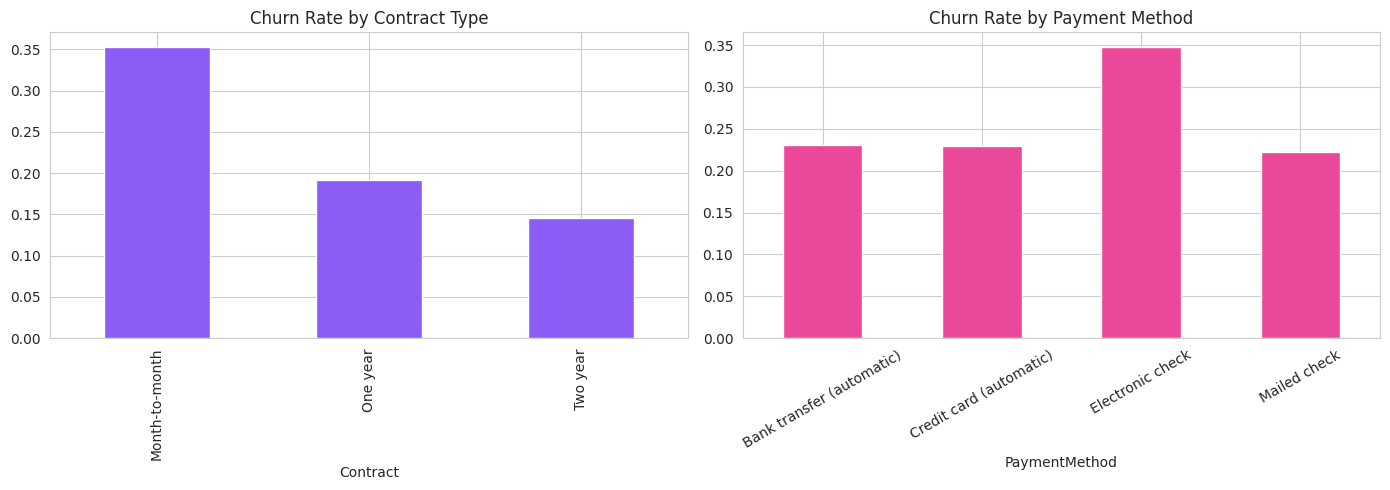

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('Contract')['Churn'].mean().plot(kind='bar', ax=axes[0], color='#8b5cf6')
axes[0].set_title('Churn Rate by Contract Type')
df.groupby('PaymentMethod')['Churn'].mean().plot(kind='bar', ax=axes[1], color='#ec4899')
axes[1].set_title('Churn Rate by Payment Method')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 7. Key Takeaways

- Month-to-month contracts and electronic-check payment correlate strongly with higher churn.
- Fiber-optic internet customers churn more than DSL customers, despite (or because of) higher spend.
- Customers without tech support / online security churn more — these add-ons appear protective.
- Churn risk drops sharply as tenure increases — the first ~12 months are the highest-risk window.
- These patterns directly informed the engineered features (`RiskScore`, `EngagementScore`,
  `ServiceUsageScore`) used in the modeling pipeline (see `src/feature_engineering.py`).